## Experiment No: 6
## Experiment Title: Logistic Regression — Spam Classification

**Name:** Himanshu Jadhav  
**Roll Number:** SE-33


## 📌 Problem Statement

- Load the Spambase dataset.
- Train a Logistic Regression model to classify emails as spam or not spam.
- Evaluate the model using accuracy score and confusion matrix.

> **Dataset:** https://www.kaggle.com/datasets/colormap/spambase

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

In [2]:
# Load The Dataset

df = pd.read_csv("spambase.csv")
print("Shape: ",df.shape)
print(df.head())

Shape:  (4601, 58)
   word_freq_make  word_freq_address  word_freq_all  word_freq_3d  \
0            0.00               0.64           0.64           0.0   
1            0.21               0.28           0.50           0.0   
2            0.06               0.00           0.71           0.0   
3            0.00               0.00           0.00           0.0   
4            0.00               0.00           0.00           0.0   

   word_freq_our  word_freq_over  word_freq_remove  word_freq_internet  \
0           0.32            0.00              0.00                0.00   
1           0.14            0.28              0.21                0.07   
2           1.23            0.19              0.19                0.12   
3           0.63            0.00              0.31                0.63   
4           0.63            0.00              0.31                0.63   

   word_freq_order  word_freq_mail  ...  char_freq_;  char_freq_(  \
0             0.00            0.00  ...         0.00

In [3]:
# Preparing Features and Target

x = df.iloc[:, :-1]
y = df.iloc[:, -1]

print(f"Features: {x.shape}, Target Distribution: ")
print(y.value_counts())

Features: (4601, 57), Target Distribution: 
spam
0    2788
1    1813
Name: count, dtype: int64


In [4]:
# Scalar Features 

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [5]:
# Data Splitting 

x_train, x_test, y_train, y_test = train_test_split(
    x_scaled, y, test_size=0.2, random_state=42
)
print(f"Train: {x_train.shape}, Test: {x_test.shape}")

Train: (3680, 57), Test: (921, 57)


In [6]:
# Model Training

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(x_train, y_train)
print("Model Train Successfully...")

Model Train Successfully...


In [7]:
# Predict and Evaluate the Accuracy

y_pred = model.predict(x_test)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc * 100:.2f}%")
print("\nClassification Report: ")
print(classification_report(y_test, y_pred, target_names=['Not Spam', 'Spam']))


Accuracy: 91.97%

Classification Report: 
              precision    recall  f1-score   support

    Not Spam       0.91      0.95      0.93       531
        Spam       0.93      0.87      0.90       390

    accuracy                           0.92       921
   macro avg       0.92      0.91      0.92       921
weighted avg       0.92      0.92      0.92       921



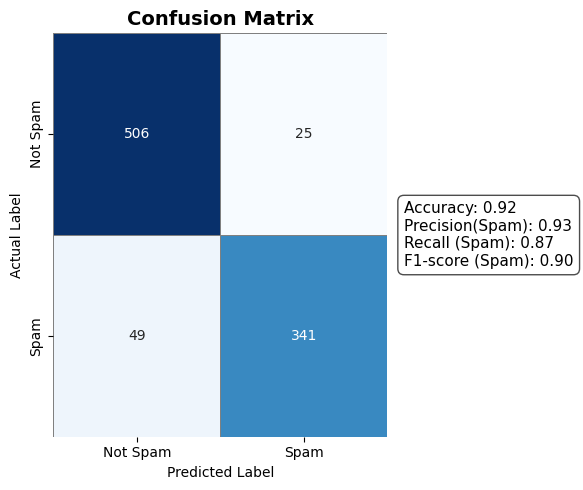

In [8]:
# Plot for Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Spam', 'Spam'],
            yticklabels=['Not Spam', 'Spam'],
            cbar=False, linewidths=0.5, linecolor='gray')

plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontweight=12)
plt.ylabel('Actual Label', fontweight=12)

report = classification_report(y_test, y_pred, target_names=['Not Spam','Spam'], output_dict=True)
metrics_text = (
    f"Accuracy: {report['accuracy']:.2f}\n"
    f"Precision(Spam): {report['Spam']['precision']:.2f}\n"
    f"Recall (Spam): {report['Spam']['recall']:.2f}\n"
    f"F1-score (Spam): {report['Spam']['f1-score']:.2f}"
)

plt.text(1.05, 0.5, metrics_text, transform=plt.gca().transAxes,
         fontsize=11, verticalalignment='center',
         bbox=dict(boxstyle="round, pad=0.4",facecolor="white", alpha=0.7))

plt.tight_layout()
plt.show()
